# Reconnaissance de panneaux GTSRB — Méthode classique avec comme descripteur la signature

Pipeline complet :
1. Chargement GTSRB + mapping 43 classes → 4 formes
2. Prétraitement : normalisation BGR → K-means K=3 → sélection cluster rouge → masque binaire
3. Signature polaire `r(θ)` — méthode `mySignature` de `shape.py`
4. Filtre gaussien → **FFT** → fréquence dominante → classification
5. Évaluation : matrice de confusion, bonnes réponses, performance moyenne par forme

In [1]:
import os, csv, math, warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import scipy as sc
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)

print('OpenCV :', cv2.__version__)

OpenCV : 4.13.0


## 1. Configuration et mapping GTSRB → 5 formes

In [2]:
DATA_DIR      = '/content/GTSRB/Final_Training/Images'
MAX_PAR_FORME = 500   # limite par forme pour équilibrage

SHAPE_MAP = {
    'circle':   [0,1,2,3,4,5,6,7,8,9,10,15,16,17,32,33,34,35,36,37,38,39,40,41,42],
    'triangle': [11,18,19,20,21,22,23,24,25,26,27,28,29,30,31],
    'octagon':  [14],
    'other':    [12, 13],   # diamond (12) + inv_triangle (13)
}

# Vérification exhaustivité
all_ids = [i for ids in SHAPE_MAP.values() for i in ids]
assert len(all_ids) == 43 and len(set(all_ids)) == 43, 'Mapping incomplet'
print('Mapping OK — 43 classes couvertes')
for shape, ids in SHAPE_MAP.items():
    print(f'  {shape:<12} : {len(ids)} classes')

Mapping OK — 43 classes couvertes
  circle       : 25 classes
  triangle     : 15 classes
  octagon      : 1 classes
  other        : 2 classes


## 2. Téléchargement du dataset (Colab)

In [3]:
!rm -rf GTSRB GTSRB_Final_Training_Images.zip
!wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!unzip -q GTSRB_Final_Training_Images.zip
print('Dataset extrait :', os.path.exists(DATA_DIR))

Dataset extrait : True


## 3. Chargement des images (recadrage ROI)

In [4]:
def charger_gtsrb(root, shape_map, max_par_forme):
    images, labels = [], []
    counts = {s: 0 for s in shape_map}

    for forme, class_ids in shape_map.items():
        for cls_id in class_ids:
            if counts[forme] >= max_par_forme:
                break
            folder   = os.path.join(root, f'{cls_id:05d}')
            csv_path = os.path.join(folder, f'GT-{cls_id:05d}.csv')
            if not os.path.isdir(folder):
                continue
            if not os.path.exists(csv_path):
                for fname in sorted(os.listdir(folder)):
                    if counts[forme] >= max_par_forme: break
                    if not fname.lower().endswith('.ppm'): continue
                    img = cv2.imread(os.path.join(folder, fname))
                    if img is not None:
                        images.append(img); labels.append(forme); counts[forme] += 1
                continue
            with open(csv_path, newline='') as f:
                for row in csv.DictReader(f, delimiter=';'):
                    if counts[forme] >= max_par_forme: break
                    img = cv2.imread(os.path.join(folder, row['Filename']))
                    if img is None: continue
                    try:
                        x1,y1,x2,y2 = int(row['Roi.X1']),int(row['Roi.Y1']),int(row['Roi.X2']),int(row['Roi.Y2'])
                        img = img[y1:y2, x1:x2]
                    except (KeyError, ValueError): pass
                    if img.size > 0:
                        images.append(img); labels.append(forme); counts[forme] += 1
    return images, labels, counts

images, labels, counts = charger_gtsrb(DATA_DIR, SHAPE_MAP, MAX_PAR_FORME)
print(f'Total : {len(images)} images')
for k, v in counts.items(): print(f'  {k:<15} : {v}')

Total : 2000 images
  circle          : 500
  triangle        : 500
  octagon         : 500
  other           : 500


## 4. Prétraitement et extraction de la signature

In [5]:
def my_signature(objet_binaire):
    """Reproduction exacte de mySignature() de shape.py."""
    contour, _ = cv2.findContours(objet_binaire, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contour:
        return []
    cnt = max(contour, key=cv2.contourArea)
    ch  = np.mean(cnt[:, 0, 0])
    cw  = np.mean(cnt[:, 0, 1])
    signature = []
    for p in cnt:
        d = math.sqrt((p[0, 0] - ch)**2 + (p[0, 1] - cw)**2)
        signature.append(d)
    return signature


# Couleur cible : rouge normalisé [0, 1] en BGR
COULEUR_CIBLE = np.array([0, 0, 1], dtype=float)
K_MEANS       = 3
TAILLE_MIN    = 100   # aire minimale en pixels pour filtrer le bruit


def kmeans_masque_rouge(img_bgr):
    """
    Reproduit le pipeline de TP1_recoPanneaux.py :
      1. Normalisation BGR → [0, 1]
      2. K-means K=3
      3. Sélection du cluster le plus proche de la couleur rouge [0, 0, 1]
      4. Masque binaire 0/255
    """
    # Normalisation
    imrgb = img_bgr.astype(np.float32) / 255.0
    h, w  = imrgb.shape[:2]
    pixels = imrgb.reshape(-1, 3)

    # K-means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(
        pixels, K_MEANS, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS
    )
    labels = labels.reshape(h, w)

    # Cluster le plus proche de [0, 0, 1] (rouge)
    dist = np.sum(np.abs(centers - COULEUR_CIBLE), axis=1)
    k    = np.argmin(dist)

    # Masque binaire
    masque = np.uint8(np.where(labels == k, 255, 0))
    return masque, labels, centers


def extraire_signatures_image(img_bgr):
    """
    Applique le pipeline complet sur une image et retourne
    la liste des signatures (une par région valide).
    """
    masque, _, _ = kmeans_masque_rouge(img_bgr)

    # Remplissage des contours (comme dans le .py)
    contours, _ = cv2.findContours(masque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    imshapes = masque.copy()
    for cnt in contours:
        cv2.drawContours(imshapes, [cnt], 0, 255, -1)

    # Composantes connexes
    _, regions, stats, _ = cv2.connectedComponentsWithStats(imshapes)

    signatures = []
    for r in range(1, len(stats)):
        if stats[r, 4] > TAILLE_MIN:
            objet = np.uint8(np.where(regions == r, 255, 0))
            sig   = my_signature(objet)
            if len(sig) > 0:
                signatures.append(sig)
    return signatures


def reeechantillonner(sig_brute, n_points=360):
    """
    Ré-échantillonne la signature brute sur une grille angulaire uniforme
    et normalise l'amplitude entre 0 et 1.
    """
    sig = np.array(sig_brute, dtype=float)
    # Interpolation linéaire sur n_points réguliers
    idx_orig = np.linspace(0, len(sig) - 1, len(sig))
    idx_new  = np.linspace(0, len(sig) - 1, n_points)
    sig = np.interp(idx_new, idx_orig, sig)
    if sig.max() > 0:
        sig = sig / sig.max()
    return sig


print('Pipeline K-means + signature défini.')

Pipeline K-means + signature défini.


## Visualisation de la binarisation

Pour chaque forme, on affiche : image originale → niveaux de gris → résultat Otsu.

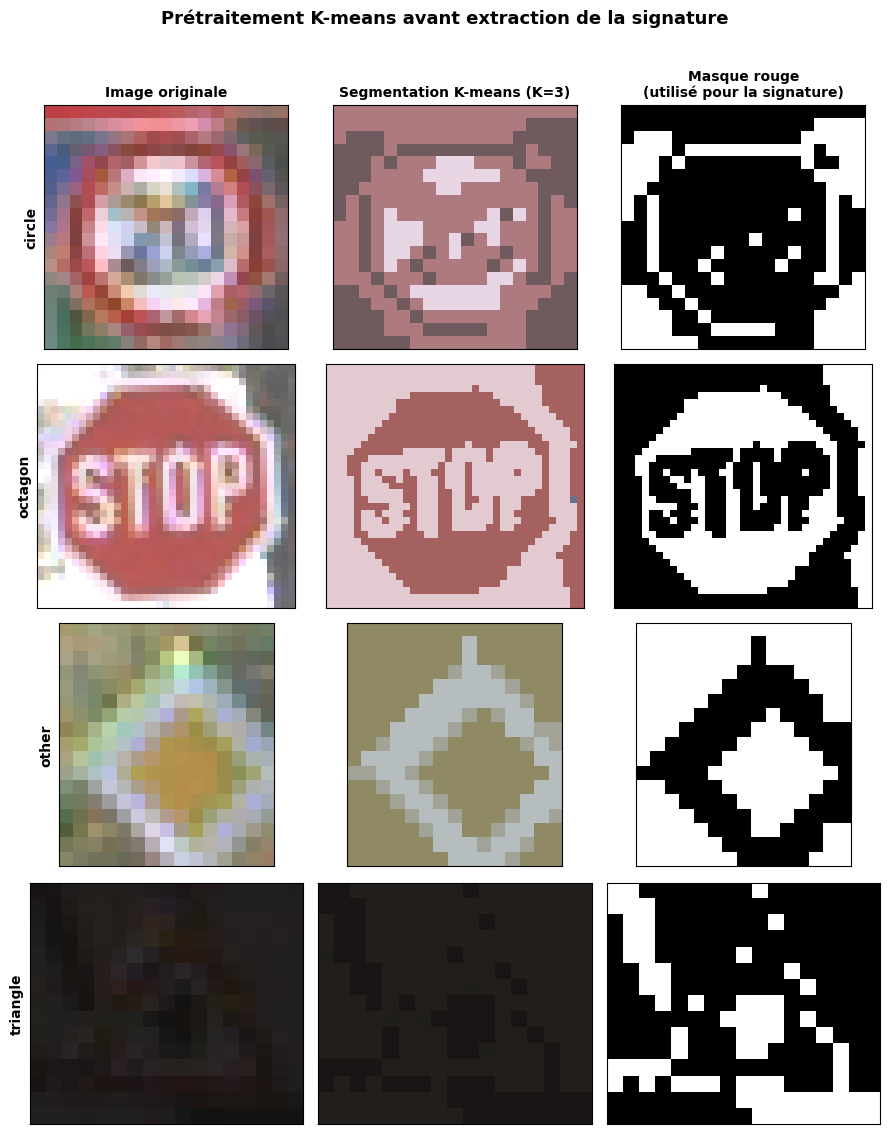

In [6]:
# 1 exemple par forme
exemples = {}
for img, lbl in zip(images, labels):
    if lbl not in exemples:
        exemples[lbl] = img
    if len(exemples) == len(SHAPE_MAP):
        break

formes_ordre = sorted(exemples.keys())
n = len(formes_ordre)

fig, axes = plt.subplots(n, 3, figsize=(9, n * 2.8))
fig.suptitle('Prétraitement K-means avant extraction de la signature',
             fontsize=13, fontweight='bold', y=1.01)

axes[0, 0].set_title('Image originale',              fontsize=10, fontweight='bold')
axes[0, 1].set_title('Segmentation K-means (K=3)',   fontsize=10, fontweight='bold')
axes[0, 2].set_title('Masque rouge\n(utilisé pour la signature)',
                      fontsize=10, fontweight='bold')

for row, forme in enumerate(formes_ordre):
    img    = exemples[forme]
    masque, labels_km, centers = kmeans_masque_rouge(img)

    # Image segmentée : chaque pixel prend la couleur de son centroïde
    h, w = img.shape[:2]
    seg  = centers[labels_km.reshape(-1)].reshape(h, w, 3)
    seg  = np.uint8(seg * 255)

    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_ylabel(forme, fontsize=10, fontweight='bold')
    axes[row, 1].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    axes[row, 2].imshow(masque, cmap='gray')

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 5. Classification par signature

Pour chaque image :
1. Rotation au minimum (normalisation de phase)
2. Filtre gaussien σ = L/128
3. FFT sur signal centré-réduit → **fréquence dominante**

Règle de décision :

- Fréquence dominante = 3 → triangle
- Fréquence dominante = 8 → octagon
- std < seuil → circle
- sinon → other (diamond, inv_triangle)

In [7]:
def classifier(sig_brute):
    """Règle directe FFT sur la signature brute."""
    if sig_brute is None or len(sig_brute) == 0:
        return 'other'

    sig = reeechantillonner(sig_brute)

    # Rotation au minimum
    sig = np.roll(sig, -int(np.argmin(sig)))

    # Filtre gaussien
    sigma = len(sig) / 128.0
    sig   = sc.ndimage.gaussian_filter(sig, sigma, order=0)

    # FFT sur signal centré-réduit
    mean_s, std_s = float(np.mean(sig)), float(np.std(sig))
    s_norm = (sig - mean_s) / std_s if std_s != 0 else sig - mean_s
    A   = np.abs(np.fft.rfft(s_norm))
    dom = int(np.argmax(A[1:]) + 1)

    if dom == 3:   return 'triangle'
    if dom == 8:   return 'octagon'
    if (std_s < 0.02 * mean_s) if mean_s != 0 else (std_s < 1e-4):
        return 'circle'
    return 'other'


# Extraction + classification sur tout le dataset
print('Extraction des signatures et classification...')
y_true, y_pred = [], []

for img, lbl in zip(images, labels):
    sigs = extraire_signatures_image(img)
    # On prend la première région valide (la plus grande est déjà filtrée)
    pred = classifier(sigs[0]) if sigs else 'other'
    y_true.append(lbl)
    y_pred.append(pred)

print(f'Traité : {len(y_true)} images')

Extraction des signatures et classification...
Traité : 2000 images


## 6. Résultats et métriques

In [11]:
classes = sorted(SHAPE_MAP.keys())

acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 45)
print(f'  Bonnes réponses (accuracy)      : {acc*100:.2f}%')
print(f'  Performance moyenne par forme   : {f1m*100:.2f}%')
print('=' * 45)
print()
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

  Bonnes réponses (accuracy)      : 35.35%
  Performance moyenne par forme   : 29.80%

              precision    recall  f1-score   support

      circle       1.00      0.07      0.12       500
     octagon       1.00      0.26      0.42       500
       other       0.28      0.94      0.43       500
    triangle       0.50      0.14      0.22       500

    accuracy                           0.35      2000
   macro avg       0.69      0.35      0.30      2000
weighted avg       0.69      0.35      0.30      2000



## 7. Matrice de confusion

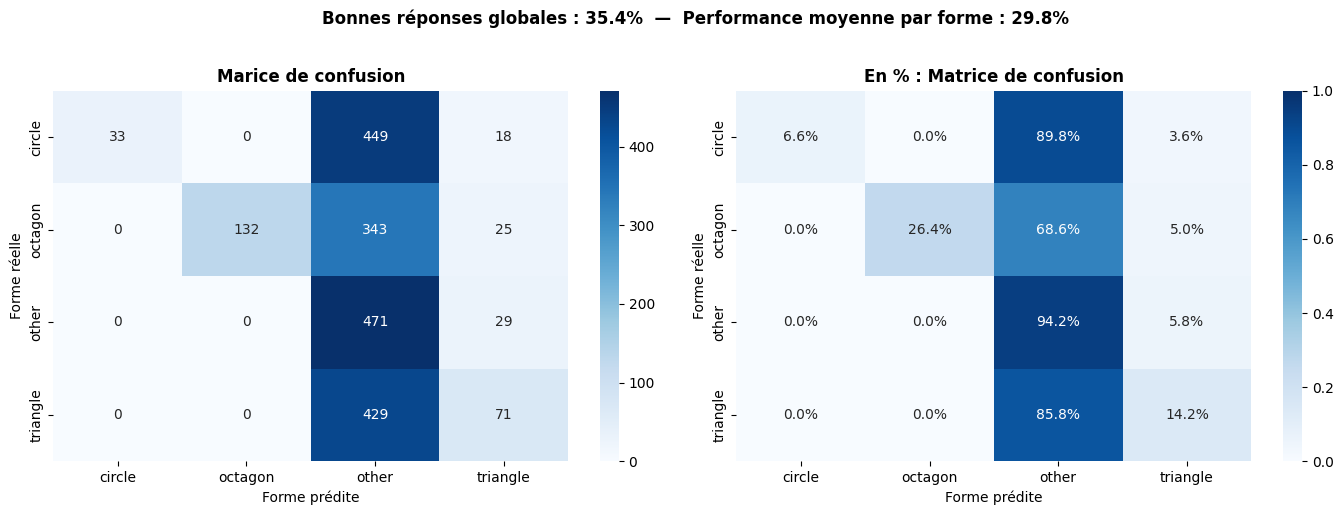

In [12]:
cm     = confusion_matrix(y_true, y_pred, labels=classes)
cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Marice de confusion', fontweight='bold')
axes[0].set_xlabel('Forme prédite')
axes[0].set_ylabel('Forme réelle')

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('En % : Matrice de confusion', fontweight='bold')
axes[1].set_xlabel('Forme prédite')
axes[1].set_ylabel('Forme réelle')

plt.suptitle(
    f'Bonnes réponses globales : {acc*100:.1f}%  —  Performance moyenne par forme : {f1m*100:.1f}%',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 8. F1 / Précision / Rappel par classe

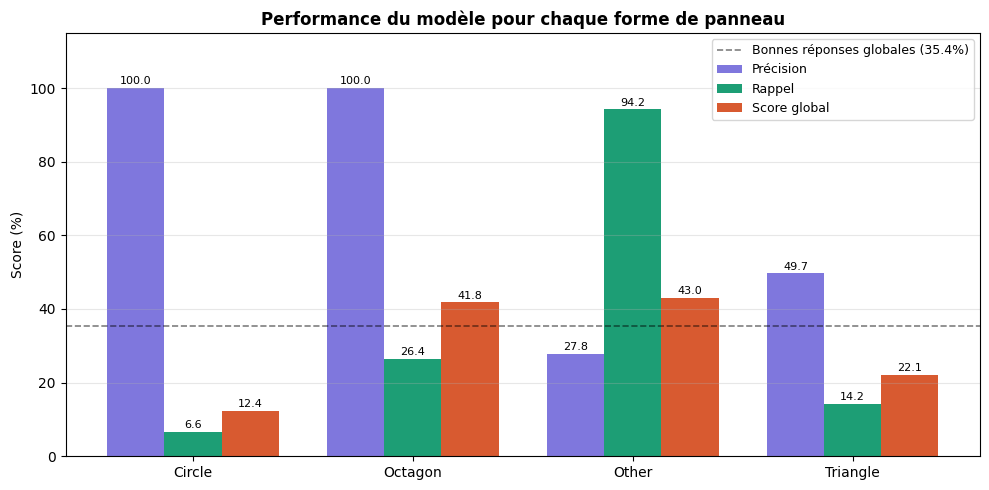

In [13]:
from sklearn.metrics import precision_score, recall_score

f1_pc   = f1_score(y_true, y_pred,        average=None, labels=classes, zero_division=0)
prec_pc = precision_score(y_true, y_pred, average=None, labels=classes, zero_division=0)
rec_pc  = recall_score(y_true, y_pred,    average=None, labels=classes, zero_division=0)

x     = np.arange(len(classes))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, prec_pc*100, width, label='Précision', color='#7F77DD')
b2 = ax.bar(x,         rec_pc*100,  width, label='Rappel',              color='#1D9E75')
b3 = ax.bar(x + width, f1_pc*100,   width, label='Score global',                    color='#D85A30')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ').capitalize() for c in classes])
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Performance du modèle pour chaque forme de panneau', fontweight='bold')
ax.axhline(acc*100, color='black', ls='--', lw=1.2, alpha=0.5,
           label=f'Bonnes réponses globales ({acc*100:.1f}%)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()